# 05. SQL Analysis on BI Star Schema

**Goal:** Perform exploratory analysis using DuckDB SQL directly on the Star Schema. 

> **Documentation Note (Filtering Closed Loans):**
> In the BI Parquet dataset, we deliberately kept over 1 million "Current" (active) loans to provide realistic volume for Power BI dashboards. However, these active loans have an unknown outcome (`default_flag IS NULL`).
> 
> If we include them in our denominator when calculating default rates, the risk will be artificially diluted. Therefore, in this exploratory analysis, **we apply `WHERE default_flag IS NOT NULL`** to all queries. This ensures we evaluate the default rate strictly on loans that have completed their lifecycle (Fully Paid vs Charged Off).

In [15]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure figures directory exists
os.makedirs('../reports/figures', exist_ok=True)

# Connect to gold layer
con = duckdb.connect('../data/gold/goldBI.duckdb')

# Style
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print("Connected to goldBI")

Connected to goldBI


In [16]:
    # ── KPI 1: Overall Default Rate (Closed Loans Only) ──────────────────────────────────────────────
kpi = con.execute("""
        SELECT
            COUNT(*) AS total_closed_loans,
            SUM(default_flag) AS total_defaults,
            ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
            ROUND(SUM(loan_amnt) / 1e9, 2) AS total_funded_bn,
            ROUND(AVG(loan_amnt), 2) AS avg_loan_amount,
            ROUND(AVG(int_rate), 2) AS avg_interest_rate
        FROM fact_loans
        WHERE default_flag IS NOT NULL
    """).fetchdf()

print("=== OVERALL KPIs (Closed Loans) ===")
print(kpi.to_string(index=False))

=== OVERALL KPIs (Closed Loans) ===
 total_closed_loans  total_defaults  default_rate_pct  total_funded_bn  avg_loan_amount  avg_interest_rate
            1368244        290519.0             21.23            19.77         14449.76               0.13


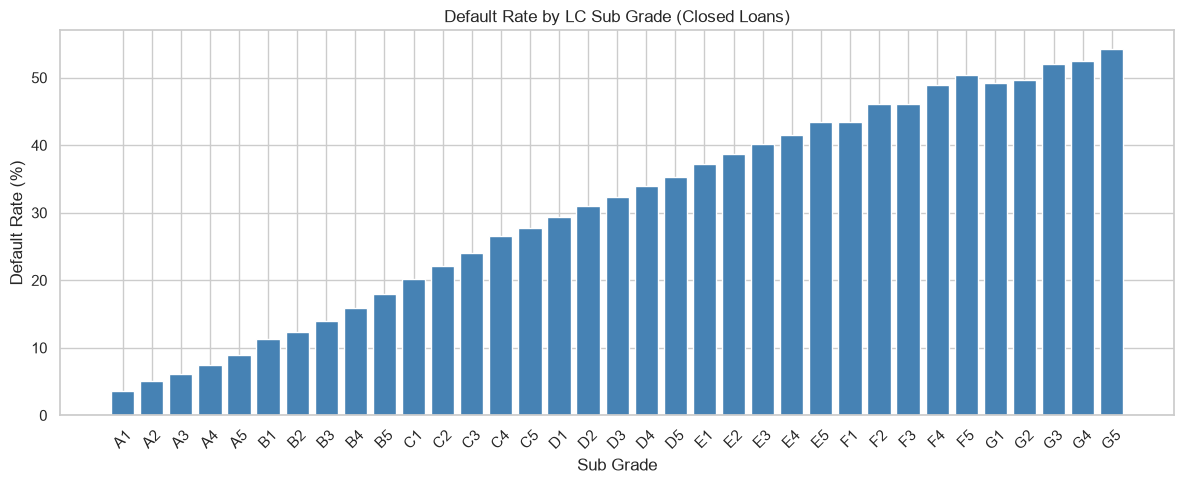

sub_grade  total_loans  default_rate_pct  avg_int_rate
       A1        43811              3.55          0.06
       A2        37355              5.15          0.07
       A3        38229              6.12          0.07
       A4        52560              7.46          0.08
       A5        64434              8.99          0.08
       B1        71892             11.35          0.09
       B2        74793             12.28          0.10
       B3        82708             13.90          0.11
       B4        84307             15.95          0.11
       B5        83904             18.03          0.12


In [17]:
# ── KPI 2: Default Rate by Sub Grade ──────────────────────────────────────────────
by_grade = con.execute("""
    SELECT
        dr.sub_grade,
        COUNT(*) AS total_loans,
        ROUND(AVG(f.default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(f.int_rate), 2) AS avg_int_rate
    FROM fact_loans f
    JOIN dim_risk dr ON f.risk_key = dr.risk_key
    WHERE f.default_flag IS NOT NULL
    GROUP BY dr.sub_grade
    ORDER BY dr.sub_grade
""").fetchdf()

# Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(by_grade['sub_grade'], by_grade['default_rate_pct'], color='steelblue')
ax.set_xlabel('Sub Grade')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by LC Sub Grade (Closed Loans)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/default_by_subgrade.png')
plt.show()

print(by_grade.head(10).to_string(index=False))

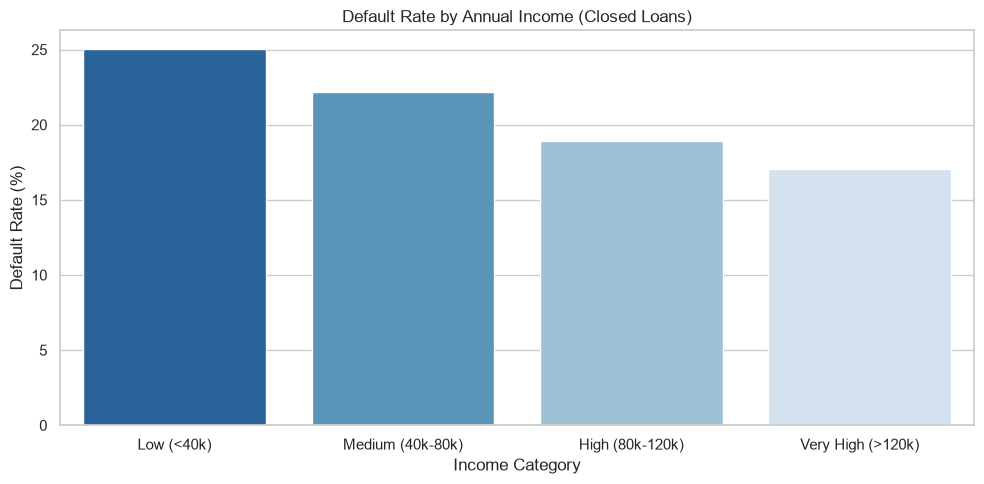

annual_inc_category  total_loans  default_rate_pct
         Low (<40k)       214112             25.02
   Medium (40k-80k)       674692             22.17
    High (80k-120k)       306744             18.89
  Very High (>120k)       172696             17.03


In [18]:
# ── KPI 3: Default Rate by Annual Income Category ────────────────────────────────────────
by_income = con.execute("""
    SELECT
        annual_inc_category,
        COUNT(*) AS total_loans,
        ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct
    FROM fact_loans
    WHERE default_flag IS NOT NULL
    GROUP BY annual_inc_category
    ORDER BY default_rate_pct DESC
""").fetchdf()

fig, ax = plt.subplots()
sns.barplot(data=by_income, x='annual_inc_category', y='default_rate_pct', ax=ax, palette='Blues_r', hue='annual_inc_category', legend=False)
ax.set_xlabel('Income Category')
ax.set_ylabel('Default Rate (%)')
ax.set_title('Default Rate by Annual Income (Closed Loans)')
plt.tight_layout()
plt.savefig('../reports/figures/default_by_income.png')
plt.show()

print(by_income.to_string(index=False))

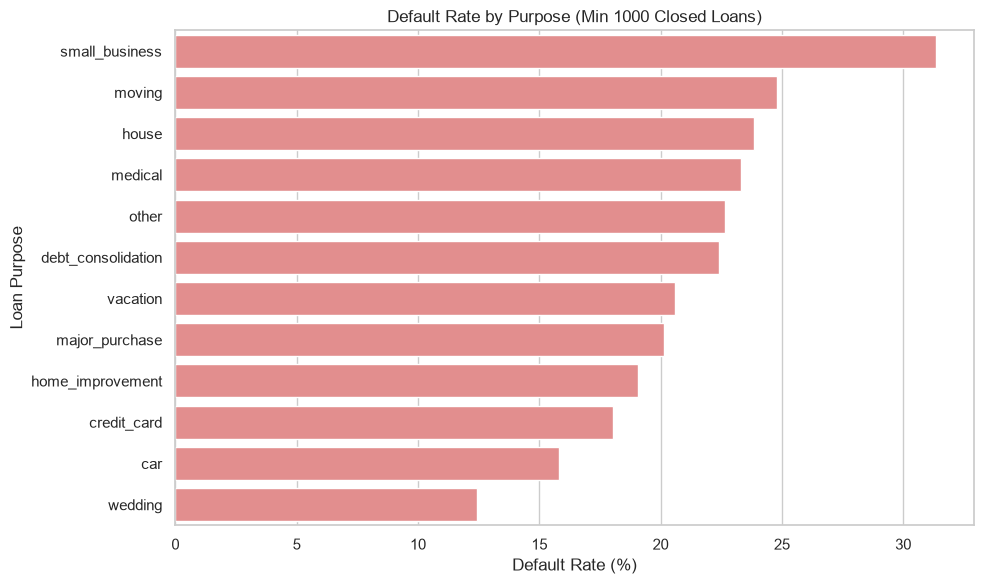

In [19]:
# ── KPI 4: Default Rate by Loan Purpose ──────────────────────────────────────────────
by_purpose = con.execute("""
    SELECT
        dp.purpose,
        COUNT(*) AS total_loans,
        ROUND(AVG(f.default_flag) * 100, 2) AS default_rate_pct
    FROM fact_loans f
    JOIN dim_purpose dp ON f.purpose_key = dp.purpose_key
    WHERE f.default_flag IS NOT NULL
    GROUP BY dp.purpose
    HAVING COUNT(*) > 1000
    ORDER BY default_rate_pct DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=by_purpose, y='purpose', x='default_rate_pct', ax=ax, color='lightcoral')
ax.set_ylabel('Loan Purpose')
ax.set_xlabel('Default Rate (%)')
ax.set_title('Default Rate by Purpose (Min 1000 Closed Loans)')
plt.tight_layout()
plt.savefig('../reports/figures/default_by_purpose.png')
plt.show()


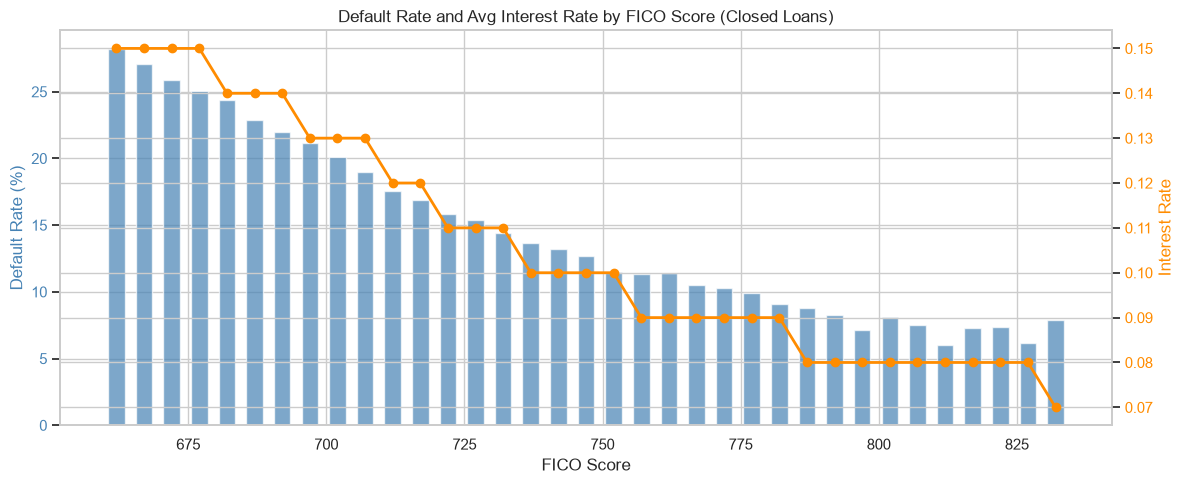

In [20]:
# ── KPI 5: Interest Rate vs Default Rate by FICO Range ──────────────────────────────────
by_fico = con.execute("""
    SELECT
        fico_score AS fico,
        COUNT(*) AS total_loans,
        ROUND(AVG(default_flag) * 100, 2) AS default_rate_pct,
        ROUND(AVG(int_rate), 2) AS avg_int_rate
    FROM fact_loans
    WHERE default_flag IS NOT NULL
    GROUP BY fico_score
    HAVING COUNT(*) > 500
    ORDER BY fico_score
""").fetchdf()

fig, ax1 = plt.subplots(figsize=(12, 5))

# Bar chart for default rate
ax1.bar(by_fico['fico'], by_fico['default_rate_pct'], width=3, color='steelblue', alpha=0.7, label='Default Rate (%)')
ax1.set_xlabel('FICO Score')
ax1.set_ylabel('Default Rate (%)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Line chart for interest rate
ax2 = ax1.twinx()
ax2.plot(by_fico['fico'], by_fico['avg_int_rate'], color='darkorange', marker='o', linewidth=2, label='Avg Interest Rate')
ax2.set_ylabel('Interest Rate', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Default Rate and Avg Interest Rate by FICO Score (Closed Loans)')
fig.tight_layout()
plt.savefig('../reports/figures/fico_analysis.png')
plt.show()


In [21]:
con.close()
print("Analysis complete and plots saved to reports/figures/")

Analysis complete and plots saved to reports/figures/
